# HW12 – Временные ряды: temporal split, baseline-модели и GRU-прогноз

**Датасет:** `S12-hw-dataset.csv`  
**Задача:** прогноз временного ряда `target` (почасовые данные)  
**Эксперименты:** B1 (naive-last), B2 (moving-average), B3 (ridge-lag-features), R1 (gru-forecast)

## 1. Импорты, seed и среда

In [9]:
import math
import random
import json
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print("Библиотеки импортированы.")

Библиотеки импортированы.


In [10]:
SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seed: {SEED}")
print(f"Device: {device}")

Seed: 42
Device: cuda


## 2. Данные и первичный анализ

In [11]:
df = pd.read_csv("S12-hw-dataset.csv")

# Приводим дату к datetime и сортируем по времени
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [12]:
# Sanity-check: базовая информация о датасете
print(f"Число наблюдений : {len(df)}")
print(f"Диапазон дат     : {df['date'].min()} → {df['date'].max()}")
print(f"Частота          : почасовая")
print()
print("Пропуски по колонкам:")
print(df.isnull().sum())
print()
print("Базовая статистика:")
display(df.describe())

Число наблюдений : 4320
Диапазон дат     : 2025-01-01 00:00:00 → 2025-06-29 23:00:00
Частота          : почасовая

Пропуски по колонкам:
date      0
target    0
dtype: int64

Базовая статистика:


,date,target
count,4320,4320.000000
mean,2025-03-31 23:29:59.999999744,135.605840
min,2025-01-01 00:00:00,69.100000
25%,2025-02-14 23:45:00,120.537500
50%,2025-03-31 23:30:00,135.835000
75%,2025-05-15 23:15:00,150.625000
max,2025-06-29 23:00:00,210.100000
std,NaN,21.384633


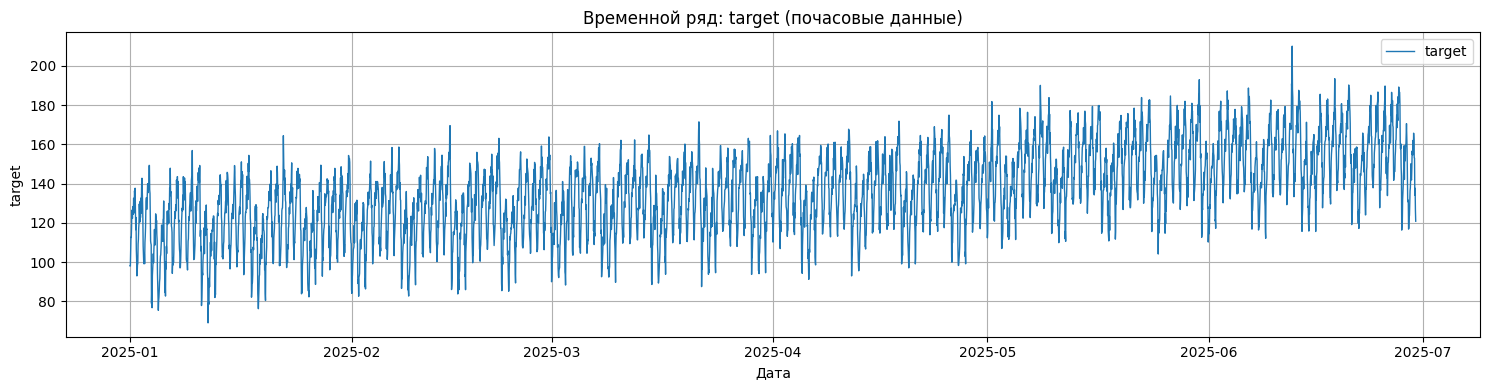

In [13]:
# Базовый график временного ряда
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df["date"], df["target"], lw=1.0, label="target")
ax.set_title("Временной ряд: target (почасовые данные)")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
plt.tight_layout()
plt.show()

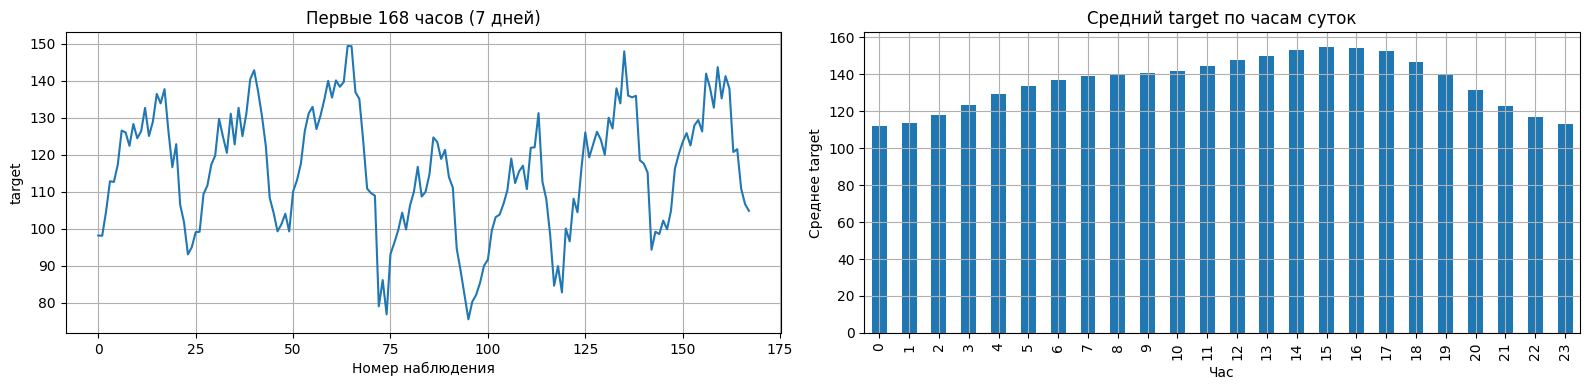


Комментарий к ряду:
- Ряд имеет выраженную суточную сезонность (периодические пики и спады в течение дня).
- Заметна долгосрочная нестабильность уровня — возможен слабый тренд или сдвиги режима.
- Присутствуют выбросы (значения, заметно выше типичного диапазона).
- Пропусков в данных нет, что упрощает постановку задачи.
- Рассматриваем как стационарный ряд с сезонностью — типичный кандидат для лаговых моделей и GRU.



In [14]:
# Крупный план: первые 7 суток (168 часов) — видна суточная сезонность
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df["target"].iloc[:168].plot(ax=axes[0], title="Первые 168 часов (7 дней)")
axes[0].set_xlabel("Номер наблюдения")
axes[0].set_ylabel("target")

# Средние значения по часам суток
df.assign(hour=df["date"].dt.hour).groupby("hour")["target"].mean().plot(
    kind="bar", ax=axes[1], title="Средний target по часам суток"
)
axes[1].set_xlabel("Час")
axes[1].set_ylabel("Среднее target")

plt.tight_layout()
plt.show()

print("""
Комментарий к ряду:
- Ряд имеет выраженную суточную сезонность (периодические пики и спады в течение дня).
- Заметна долгосрочная нестабильность уровня — возможен слабый тренд или сдвиги режима.
- Присутствуют выбросы (значения, заметно выше типичного диапазона).
- Пропусков в данных нет, что упрощает постановку задачи.
- Рассматриваем как стационарный ряд с сезонностью — типичный кандидат для лаговых моделей и GRU.
""")

## 3. Корректный temporal split

Для временных рядов задача всегда звучит: **«используя прошлое, предсказать будущее»**.

При `random split` модель обучается на будущих точках и тестируется на прошлых — это нереалистичный сценарий, который приводит к завышенным метрикам. Кроме того, лаговые признаки из будущего просачиваются в обучение (leakage). Поэтому используем **строго хронологический** split.

In [15]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    """
    Разбивает DF на train/val/test строго по хронологии.
    Никакого перемешивания строк перед разбиением.
    """
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()
    val_df   = df.iloc[train_end:val_end].copy()
    test_df  = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_raw, val_raw, test_raw = temporal_split(df)

print(f"train: {train_raw['date'].min()} → {train_raw['date'].max()} | {len(train_raw)} строк ({100*len(train_raw)/len(df):.1f}%)")
print(f"val  : {val_raw['date'].min()} → {val_raw['date'].max()} | {len(val_raw)} строк ({100*len(val_raw)/len(df):.1f}%)")
print(f"test : {test_raw['date'].min()} → {test_raw['date'].max()} | {len(test_raw)} строк ({100*len(test_raw)/len(df):.1f}%)")

train: 2025-01-01 00:00:00 → 2025-05-06 23:00:00 | 3024 строк (70.0%)
val  : 2025-05-07 00:00:00 → 2025-06-02 23:00:00 | 648 строк (15.0%)
test : 2025-06-03 00:00:00 → 2025-06-29 23:00:00 | 648 строк (15.0%)


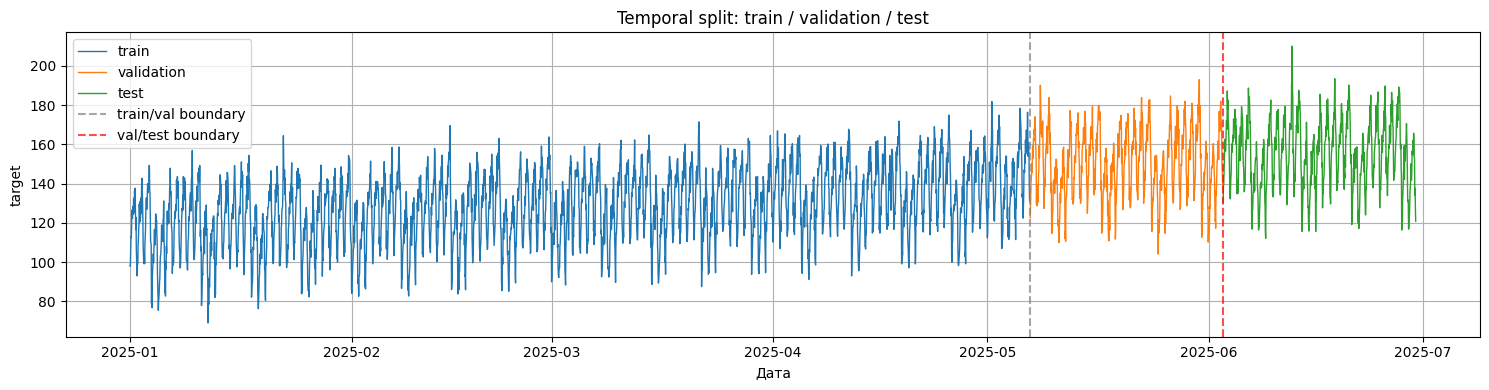

Сохранено: artifacts/figures/series_split.png


In [16]:
# Визуализация split
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_raw["date"], train_raw["target"], label="train", lw=1.0)
ax.plot(val_raw["date"],   val_raw["target"],   label="validation", lw=1.0)
ax.plot(test_raw["date"],  test_raw["target"],  label="test", lw=1.0)
ax.axvline(train_raw["date"].max(), color="gray", linestyle="--", alpha=0.7, label="train/val boundary")
ax.axvline(val_raw["date"].max(),   color="red",  linestyle="--", alpha=0.7, label="val/test boundary")
ax.set_title("Temporal split: train / validation / test")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/series_split.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/series_split.png")

## 4. Признаки для baseline-моделей

Все признаки строим из **прошлого** — только `shift(lag)` или `shift(1).rolling(...)`.  
Это гарантирует отсутствие утечки информации из будущего.

In [17]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["hour"]      = out["date"].dt.hour
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"]     = out["date"].dt.month

    # Синус/косинус кодируют цикличность без искусственного разрыва
    out["hour_sin"]  = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"]  = np.cos(2 * np.pi * out["hour"] / 24)
    out["dow_sin"]   = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"]   = np.cos(2 * np.pi * out["dayofweek"] / 7)
    return out


def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    # Обязательные лаги по заданию (lag_1, lag_7, lag_14)
    # Для почасового ряда 1 лаг = 1 час, 7 = 7 часов, 14 = 14 часов
    # Также добавляем lag_24 (сутки назад) и lag_168 (неделя назад)
    for lag in [1, 7, 14, 24, 168]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    # Rolling-признаки: shift(1) гарантирует отсутствие leakage (текущая точка не входит в окно)
    out["rolling_mean_7"]  = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"]   = out[target_col].shift(1).rolling(window=7).std()
    out["rolling_mean_24"] = out[target_col].shift(1).rolling(window=24).mean()
    out["rolling_std_24"]  = out[target_col].shift(1).rolling(window=24).std()
    return out


# Строим признаки на всём датафрейме, потом делаем temporal split
features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)

# Первые строки теряются из-за лагов и rolling — это нормально
features_df = features_df.dropna().reset_index(drop=True)
print(f"Строк после dropna: {len(features_df)} (было {len(df)})")
features_df.head(3)

Строк после dropna: 4152 (было 4320)


,date,target,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos,lag_1,lag_7,lag_14,lag_24,lag_168,rolling_mean_7,rolling_std_7,rolling_mean_24,rolling_std_24
0,2025-01-08 00:00:00,97.11,0,2,1,0.000000,1.000000,0.974928,-0.222521,104.82,141.22,129.36,98.53,98.14,120.507143,14.492322,122.167500,14.110294
1,2025-01-08 01:00:00,97.44,1,2,1,0.258819,0.965926,0.974928,-0.222521,97.11,137.81,126.26,102.16,98.07,114.205714,13.543831,122.108333,14.216298
2,2025-01-08 02:00:00,101.13,2,2,1,0.500000,0.866025,0.974928,-0.222521,97.44,120.70,141.90,99.82,104.70,108.438571,9.930756,121.911667,14.533371


In [18]:
FEATURE_COLS = [
    "hour", "dayofweek", "month",
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "lag_1", "lag_7", "lag_14", "lag_24", "lag_168",
    "rolling_mean_7", "rolling_std_7",
    "rolling_mean_24", "rolling_std_24",
]
TARGET_COL = "target"

# Temporal split на датафрейме с признаками
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[FEATURE_COLS]
y_train = train_feat[TARGET_COL]
X_val   = val_feat[FEATURE_COLS]
y_val   = val_feat[TARGET_COL]
X_test  = test_feat[FEATURE_COLS]
y_test  = test_feat[TARGET_COL]

print("Размерности:")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}   | y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")

Размерности:
X_train: (2906, 16) | y_train: (2906,)
X_val  : (623, 16)   | y_val  : (623,)
X_test : (623, 16)  | y_test : (623,)


## 5. Базовые функции оценки метрик

In [19]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE":   mean_absolute_error(y_true, y_pred),
        "RMSE":  rmse(y_true, y_pred),
        "MAPE%": mape(y_true, y_pred),
    }])

print("Функции оценки готовы.")

Функции оценки готовы.


## 6. Эксперименты

### B1 – naive-last (наивный baseline)

In [20]:
# B1: прогноз = последнее известное значение (lag_1)
val_pred_b1  = val_feat["lag_1"].to_numpy()
test_pred_b1 = test_feat["lag_1"].to_numpy()

b1_val  = evaluate(y_val,  val_pred_b1,  "B1 naive-last")
b1_test = evaluate(y_test, test_pred_b1, "B1 naive-last")

print("B1 – Validation:")
display(b1_val)
print("B1 – Test:")
display(b1_test)

B1 – Validation:


,model,MAE,RMSE,MAPE%
0,B1 naive-last,6.396693,8.175679,4.361189


B1 – Test:


,model,MAE,RMSE,MAPE%
0,B1 naive-last,6.356051,8.094543,4.163056


### B2 – moving-average

In [21]:
# B2: прогноз = скользящее среднее за 24 часа (сутки)
val_pred_b2  = val_feat["rolling_mean_24"].to_numpy()
test_pred_b2 = test_feat["rolling_mean_24"].to_numpy()

b2_val  = evaluate(y_val,  val_pred_b2,  "B2 moving-average(24)")
b2_test = evaluate(y_test, test_pred_b2, "B2 moving-average(24)")

print("B2 – Validation:")
display(b2_val)
print("B2 – Test:")
display(b2_test)

B2 – Validation:


,model,MAE,RMSE,MAPE%
0,B2 moving-average(24),13.349391,16.150757,9.171783


B2 – Test:


,model,MAE,RMSE,MAPE%
0,B2 moving-average(24),13.144387,16.127936,8.749253


### B3 – Ridge на лаговых признаках

In [22]:
# Ridge чувствителен к масштабу — обучаем scaler только на train
scaler_b3 = StandardScaler()
X_train_sc = scaler_b3.fit_transform(X_train)   # fit только на train!
X_val_sc   = scaler_b3.transform(X_val)
X_test_sc  = scaler_b3.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)

val_pred_b3  = ridge.predict(X_val_sc)
test_pred_b3 = ridge.predict(X_test_sc)

b3_val  = evaluate(y_val,  val_pred_b3,  "B3 ridge-lag-features")
b3_test = evaluate(y_test, test_pred_b3, "B3 ridge-lag-features")

print("B3 – Validation:")
display(b3_val)
print("B3 – Test:")
display(b3_test)

B3 – Validation:


,model,MAE,RMSE,MAPE%
0,B3 ridge-lag-features,4.407459,5.698752,2.965725


B3 – Test:


,model,MAE,RMSE,MAPE%
0,B3 ridge-lag-features,4.340664,5.643034,2.811027


### Выбор лучшего baseline по validation

In [23]:
baseline_val = pd.concat([b1_val, b2_val, b3_val], ignore_index=True).sort_values("MAE").reset_index(drop=True)
print("Сравнение baselines на Validation:")
display(baseline_val)

Сравнение baselines на Validation:


,model,MAE,RMSE,MAPE%
0,B3 ridge-lag-features,4.407459,5.698752,2.965725
1,B1 naive-last,6.396693,8.175679,4.361189
2,B2 moving-average(24),13.349391,16.150757,9.171783


## 7. Оконное представление для GRU

In [24]:
WINDOW_SIZE = 24   # 24 часа = сутки истории как контекст
HORIZON     = 1    # прогноз на 1 шаг вперёд

# Нормализация только по train
scaler_gru = StandardScaler()
train_vals = train_raw["target"].to_numpy().reshape(-1, 1).astype(np.float32)
val_vals   = val_raw["target"].to_numpy().reshape(-1, 1).astype(np.float32)
test_vals  = test_raw["target"].to_numpy().reshape(-1, 1).astype(np.float32)

train_scaled = scaler_gru.fit_transform(train_vals)   # fit только на train!
val_scaled   = scaler_gru.transform(val_vals)
test_scaled  = scaler_gru.transform(test_vals)

print(f"Масштаб (mean={scaler_gru.mean_[0]:.3f}, std={scaler_gru.scale_[0]:.3f})")


def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует ряд в обучающие окна (X, y).
    X: (n_samples, window_size, 1) — контекст
    y: (n_samples,)               — следующее значение
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])
        y.append(series_2d[i + window_size, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


X_tr, y_tr = make_windows(train_scaled, WINDOW_SIZE)
X_vl, y_vl = make_windows(val_scaled,   WINDOW_SIZE)
X_ts, y_ts = make_windows(test_scaled,  WINDOW_SIZE)

print(f"X_train: {X_tr.shape} | y_train: {y_tr.shape}")
print(f"X_val  : {X_vl.shape} | y_val  : {y_vl.shape}")
print(f"X_test : {X_ts.shape} | y_test : {y_ts.shape}")

Масштаб (mean=128.206, std=18.482)
X_train: (3000, 24, 1) | y_train: (3000,)
X_val  : (624, 24, 1) | y_val  : (624,)
X_test : (624, 24, 1) | y_test : (624,)


In [25]:
class TimeSeriesDataset(Dataset):
    """Оборачивает numpy-массивы X, y в PyTorch Dataset."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (n, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (n,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 64

train_ds = TimeSeriesDataset(X_tr, y_tr)
val_ds   = TimeSeriesDataset(X_vl, y_vl)
test_ds  = TimeSeriesDataset(X_ts, y_ts)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print(f"Batch X: {xb.shape}")
print(f"Batch y: {yb.shape}")

Batch X: torch.Size([64, 24, 1])
Batch y: torch.Size([64])


## 8. Архитектура GRU и цикл обучения

In [26]:
class GRUForecaster(nn.Module):
    """
    GRU-модель для прогноза временных рядов.
    GRU имеет 2 вентиля (reset и update), что делает её проще LSTM.
    Архитектура: GRU -> последнее скрытое состояние -> Linear -> prediction
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 64,
                 num_layers: int = 2, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)               # (batch, window_size, hidden_size)
        last_hidden = out[:, -1, :]        # берём только последний шаг
        pred = self.head(last_hidden).squeeze(-1)
        return pred

In [27]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """Один проход по train: forward -> loss -> backward -> optimizer step."""
    model.train()
    losses = []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """Оценка loss на val/test без обновления весов."""
    model.eval()
    losses = []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())
    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=30, lr=5e-4, device=device,
              save_path="artifacts/best_gru.pt"):
    """
    Полный цикл обучения с сохранением лучших весов по val_loss.
    Возвращает историю train/val loss по эпохам.
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state    = None

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss   = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}"
              + (" ← best" if val_loss == best_val_loss else ""))

    # Восстанавливаем лучшее состояние
    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(best_state, save_path)
        print(f"\nЛучшие веса сохранены: {save_path}")

    return history

print("Функции обучения и оценки готовы.")

Функции обучения и оценки готовы.


### R1 – gru-forecast

In [28]:
GRU_HIDDEN = 64
GRU_LAYERS = 2
EPOCHS     = 30
LR         = 5e-4

set_seed(SEED)
gru_model = GRUForecaster(hidden_size=GRU_HIDDEN, num_layers=GRU_LAYERS).to(device)
print(f"GRU параметры: {sum(p.numel() for p in gru_model.parameters())}")

gru_history = fit_model(
    gru_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR, device=device,
    save_path="artifacts/best_gru.pt"
)

GRU параметры: 37889
Epoch 01 | train_loss=0.71560 | val_loss=0.68210 ← best
Epoch 02 | train_loss=0.28977 | val_loss=0.28887 ← best
Epoch 03 | train_loss=0.16272 | val_loss=0.20124 ← best
Epoch 04 | train_loss=0.15285 | val_loss=0.17643 ← best
Epoch 05 | train_loss=0.14951 | val_loss=0.17514 ← best
Epoch 06 | train_loss=0.14864 | val_loss=0.20038
Epoch 07 | train_loss=0.14671 | val_loss=0.19335
Epoch 08 | train_loss=0.14542 | val_loss=0.19075
Epoch 09 | train_loss=0.14340 | val_loss=0.20737
Epoch 10 | train_loss=0.14231 | val_loss=0.21877
Epoch 11 | train_loss=0.14027 | val_loss=0.23670
Epoch 12 | train_loss=0.13881 | val_loss=0.18731
Epoch 13 | train_loss=0.13289 | val_loss=0.22709
Epoch 14 | train_loss=0.12806 | val_loss=0.20569
Epoch 15 | train_loss=0.12298 | val_loss=0.21598
Epoch 16 | train_loss=0.11725 | val_loss=0.21689
Epoch 17 | train_loss=0.11184 | val_loss=0.16618 ← best
Epoch 18 | train_loss=0.10893 | val_loss=0.19038
Epoch 19 | train_loss=0.10584 | val_loss=0.15918 ← best

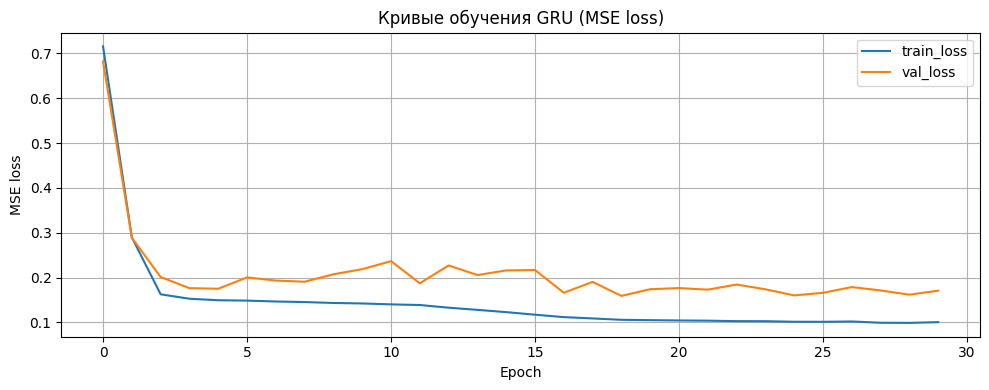

Сохранено: artifacts/figures/gru_learning_curves.png


In [29]:
# Кривые обучения GRU
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"],   label="val_loss")
ax.set_title("Кривые обучения GRU (MSE loss)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/gru_learning_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/gru_learning_curves.png")

## 9. Оценка GRU на validation и сравнение всех моделей

In [30]:
@torch.no_grad()
def predict_model(model, loader, device):
    """Получает предсказания модели в масштабированном пространстве."""
    model.eval()
    preds, targets = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()
        preds.append(outputs)
        targets.append(y_batch.numpy())
    return np.concatenate(preds), np.concatenate(targets)


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Обратное преобразование к исходному масштабу."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


# Предсказания GRU на validation
gru_val_pred_sc, gru_val_true_sc = predict_model(gru_model, val_loader, device)
gru_val_pred = inverse_scale(gru_val_pred_sc, scaler_gru)
gru_val_true = inverse_scale(gru_val_true_sc, scaler_gru)

r1_val = evaluate(gru_val_true, gru_val_pred, "R1 gru-forecast")
print("R1 GRU – Validation:")
display(r1_val)

# Сводная таблица по validation (все модели)
# Для baseline-моделей берём val_feat, у которого строк меньше из-за dropna
# GRU работает с train_raw/val_raw без dropna, поэтому часть наблюдений различается
print("\n=== Сравнение всех моделей на VALIDATION ===")
all_val = pd.concat([b1_val, b2_val, b3_val, r1_val], ignore_index=True).sort_values("MAE").reset_index(drop=True)
display(all_val)

R1 GRU – Validation:


,model,MAE,RMSE,MAPE%
0,R1 gru-forecast,5.791801,7.407583,3.873341



=== Сравнение всех моделей на VALIDATION ===


,model,MAE,RMSE,MAPE%
0,B3 ridge-lag-features,4.407459,5.698752,2.965725
1,R1 gru-forecast,5.791801,7.407583,3.873341
2,B1 naive-last,6.396693,8.175679,4.361189
3,B2 moving-average(24),13.349391,16.150757,9.171783


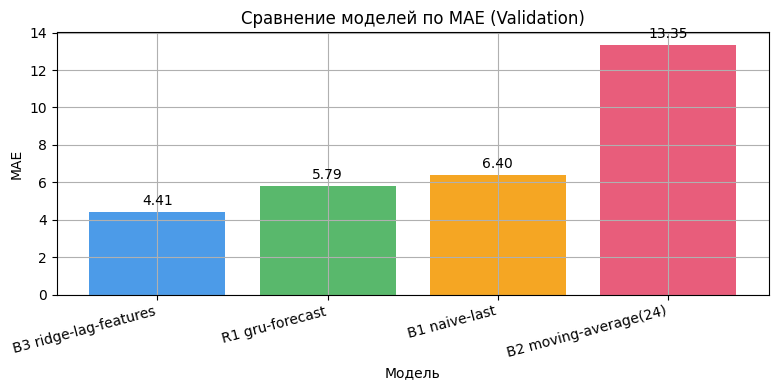

Сохранено: artifacts/figures/baselines_compare.png


In [31]:
# Визуализация сравнения моделей по MAE на validation
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4C9BE8", "#59B86C", "#F5A623", "#E85D7B"]
bars = ax.bar(all_val["model"], all_val["MAE"], color=colors)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_title("Сравнение моделей по MAE (Validation)")
ax.set_xlabel("Модель")
ax.set_ylabel("MAE")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("artifacts/figures/baselines_compare.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/baselines_compare.png")

## 10. Финальная оценка лучшей модели на TEST

Test используется **один раз** — только после того, как лучшая модель выбрана по validation.

In [32]:
best_model_by_val = all_val.iloc[0]["model"]
print(f"Лучшая модель по validation (MAE): {best_model_by_val}")

# Финальная оценка на test
gru_test_pred_sc, gru_test_true_sc = predict_model(gru_model, test_loader, device)
gru_test_pred = inverse_scale(gru_test_pred_sc, scaler_gru)
gru_test_true = inverse_scale(gru_test_true_sc, scaler_gru)

r1_test = evaluate(gru_test_true, gru_test_pred, "R1 gru-forecast")
print("\nR1 GRU – Test (финальная оценка):")
display(r1_test)

# Сводная таблица всех baseline на test
b1_test = evaluate(y_test, test_pred_b1, "B1 naive-last")
b2_test = evaluate(y_test, test_pred_b2, "B2 moving-average(24)")
b3_test = evaluate(y_test, test_pred_b3, "B3 ridge-lag-features")

print("\n=== Все модели на TEST ===")
all_test = pd.concat([b1_test, b2_test, b3_test, r1_test], ignore_index=True).sort_values("MAE").reset_index(drop=True)
display(all_test)

Лучшая модель по validation (MAE): B3 ridge-lag-features

R1 GRU – Test (финальная оценка):


,model,MAE,RMSE,MAPE%
0,R1 gru-forecast,6.699219,8.489753,4.269456



=== Все модели на TEST ===


,model,MAE,RMSE,MAPE%
0,B3 ridge-lag-features,4.340664,5.643034,2.811027
1,B1 naive-last,6.356051,8.094543,4.163056
2,R1 gru-forecast,6.699219,8.489753,4.269456
3,B2 moving-average(24),13.144387,16.127936,8.749253


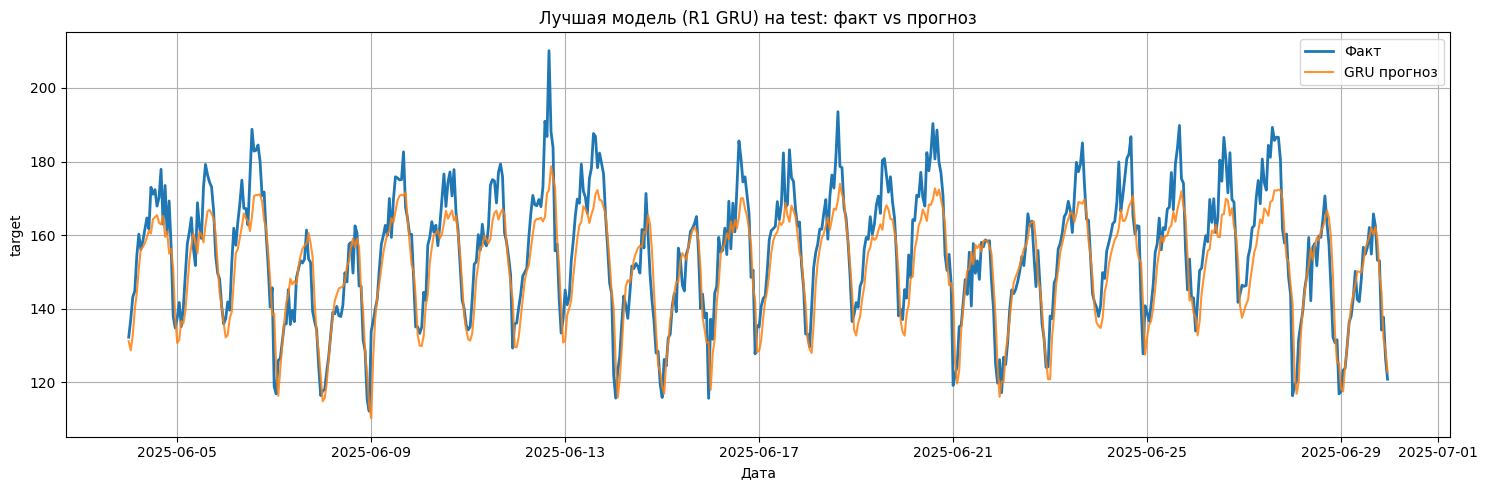

Сохранено: artifacts/figures/best_forecast_test.png


In [33]:
# График прогноза лучшей модели на test
test_dates = test_raw["date"].iloc[WINDOW_SIZE:].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_dates, gru_test_true, label="Факт", lw=2)
ax.plot(test_dates, gru_test_pred, label="GRU прогноз", lw=1.5, alpha=0.85)
ax.set_title("Лучшая модель (R1 GRU) на test: факт vs прогноз")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/best_forecast_test.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/best_forecast_test.png")

## 11. Сохранение артефактов

In [34]:
# Извлекаем метрики для runs.csv
def get_metrics(df_row):
    return df_row["MAE"].values[0], df_row["RMSE"].values[0], df_row["MAPE%"].values[0]

b1_vm, b1_vr, b1_vp = get_metrics(b1_val)
b2_vm, b2_vr, b2_vp = get_metrics(b2_val)
b3_vm, b3_vr, b3_vp = get_metrics(b3_val)
r1_vm, r1_vr, r1_vp = get_metrics(r1_val)

b1_tm, b1_tr, b1_tp = get_metrics(b1_test)
b2_tm, b2_tr, b2_tp = get_metrics(b2_test)
b3_tm, b3_tr, b3_tp = get_metrics(b3_test)
r1_tm, r1_tr, r1_tp = get_metrics(r1_test)

split_summary = f"train:70%/{len(train_raw)}, val:15%/{len(val_raw)}, test:15%/{len(test_raw)}"

runs = pd.DataFrame([
    {
        "experiment_id": "B1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": "",
        "horizon": 1,
        "model_summary": "naive-last (lag_1)",
        "features_summary": "lag_1",
        "scaler": "",
        "optimizer": "",
        "lr": "",
        "epochs_trained": "",
        "best_val_mae": round(b1_vm, 4),
        "best_val_rmse": round(b1_vr, 4),
        "best_val_mape": round(b1_vp, 4),
        "test_mae": round(b1_tm, 4),
        "test_rmse": round(b1_tr, 4),
        "test_mape": round(b1_tp, 4),
        "notes": "forecast = last observed value",
    },
    {
        "experiment_id": "B2",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": 24,
        "horizon": 1,
        "model_summary": "moving-average(24h)",
        "features_summary": "rolling_mean_24",
        "scaler": "",
        "optimizer": "",
        "lr": "",
        "epochs_trained": "",
        "best_val_mae": round(b2_vm, 4),
        "best_val_rmse": round(b2_vr, 4),
        "best_val_mape": round(b2_vp, 4),
        "test_mae": round(b2_tm, 4),
        "test_rmse": round(b2_tr, 4),
        "test_mape": round(b2_tp, 4),
        "notes": "rolling mean over 24h window",
    },
    {
        "experiment_id": "B3",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": "",
        "horizon": 1,
        "model_summary": "Ridge(alpha=1.0)",
        "features_summary": "lag_1/7/14/24/168 + rolling_mean/std_7/24 + calendar",
        "scaler": "StandardScaler (fit on train only)",
        "optimizer": "",
        "lr": "",
        "epochs_trained": "",
        "best_val_mae": round(b3_vm, 4),
        "best_val_rmse": round(b3_vr, 4),
        "best_val_mape": round(b3_vp, 4),
        "test_mae": round(b3_tm, 4),
        "test_rmse": round(b3_tr, 4),
        "test_mape": round(b3_tp, 4),
        "notes": "Ridge on lag/rolling/calendar features",
    },
    {
        "experiment_id": "R1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": WINDOW_SIZE,
        "horizon": HORIZON,
        "model_summary": f"GRU(hidden={GRU_HIDDEN}, layers={GRU_LAYERS})",
        "features_summary": "scaled target sequence",
        "scaler": "StandardScaler (fit on train only)",
        "optimizer": "Adam",
        "lr": LR,
        "epochs_trained": EPOCHS,
        "best_val_mae": round(r1_vm, 4),
        "best_val_rmse": round(r1_vr, 4),
        "best_val_mape": round(r1_vp, 4),
        "test_mae": round(r1_tm, 4),
        "test_rmse": round(r1_tr, 4),
        "test_mape": round(r1_tp, 4),
        "notes": "GRU forecaster, window=24h, best state by val_loss",
    },
])

runs.to_csv("artifacts/runs.csv", index=False)
print("Сохранено: artifacts/runs.csv")
display(runs)

Сохранено: artifacts/runs.csv


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,"train:70%/3024, val:15%/648, test:15%/648",,1,naive-last (lag_1),lag_1,,,,,6.3967,8.1757,4.3612,6.3561,8.0945,4.1631,forecast = last observed value
1,B2,forecasting,S12-hw-dataset.csv,42,"train:70%/3024, val:15%/648, test:15%/648",24,1,moving-average(24h),rolling_mean_24,,,,,13.3494,16.1508,9.1718,13.1444,16.1279,8.7493,rolling mean over 24h window
2,B3,forecasting,S12-hw-dataset.csv,42,"train:70%/3024, val:15%/648, test:15%/648",,1,Ridge(alpha=1.0),lag_1/7/14/24/168 + rolling_mean/std_7/24 + ca...,StandardScaler (fit on train only),,,,4.4075,5.6988,2.9657,4.3407,5.6430,2.8110,Ridge on lag/rolling/calendar features
3,R1,forecasting,S12-hw-dataset.csv,42,"train:70%/3024, val:15%/648, test:15%/648",24,1,"GRU(hidden=64, layers=2)",scaled target sequence,StandardScaler (fit on train only),Adam,0.0005,30,5.7918,7.4076,3.8733,6.6992,8.4898,4.2695,"GRU forecaster, window=24h, best state by val_..."


In [35]:
# Сохраняем конфиг лучшей модели GRU
gru_config = {
    "model": "GRUForecaster",
    "input_size": 1,
    "hidden_size": GRU_HIDDEN,
    "num_layers": GRU_LAYERS,
    "dropout": 0.0,
    "window_size": WINDOW_SIZE,
    "horizon": HORIZON,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "epochs": EPOCHS,
    "seed": SEED,
    "scaler": "StandardScaler",
    "scaler_mean": float(scaler_gru.mean_[0]),
    "scaler_std": float(scaler_gru.scale_[0]),
    "optimizer": "Adam",
    "criterion": "MSELoss",
    "dataset": "S12-hw-dataset.csv",
}

with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(gru_config, f, indent=2)

print("Сохранено: artifacts/best_gru_config.json")
print(json.dumps(gru_config, indent=2))

Сохранено: artifacts/best_gru_config.json
{
  "model": "GRUForecaster",
  "input_size": 1,
  "hidden_size": 64,
  "num_layers": 2,
  "dropout": 0.0,
  "window_size": 24,
  "horizon": 1,
  "batch_size": 64,
  "lr": 0.0005,
  "epochs": 30,
  "seed": 42,
  "scaler": "StandardScaler",
  "scaler_mean": 128.20576065305679,
  "scaler_std": 18.4815422838629,
  "optimizer": "Adam",
  "criterion": "MSELoss",
  "dataset": "S12-hw-dataset.csv"
}


## 12. Обсуждение: utechki и random split

**Почему `random split` некорректен:**  
Временные ряды содержат лаговые зависимости — значение в момент `t` коррелирует с `t-1`, `t-2`, и т.д.  
При случайном разбиении данные из "будущего" попадают в обучение, а данные из "прошлого" — в тест.  
В реальной задаче прогноза мы всегда предсказываем будущее на основе прошлого, поэтому `temporal split` — единственный корректный подход.

**Возможные утечки (leakage):**
1. `rolling(..., center=True)` — центрированное скользящее среднее включает будущие точки. Мы используем только `shift(1).rolling(...)` — только прошлое.
2. Fit `StandardScaler` на всём датасете перед split — тогда статистики val/test просачиваются в train. Мы делаем `fit` строго на `train`.
3. Использование таргета напрямую в признаках без сдвига — мы используем только `lag_k` (shift k).
4. Сохранение модели по метрике на test вместо validation — ведёт к переоптимизации под тест.

In [36]:
print("=== Итоговые результаты ===")
print("\nValidation:")
display(all_val)
print("\nTest (финальная оценка лучшей модели):")
display(all_test)
print(f"\nЛучшая модель по validation: {best_model_by_val}")

=== Итоговые результаты ===

Validation:


,model,MAE,RMSE,MAPE%
0,B3 ridge-lag-features,4.407459,5.698752,2.965725
1,R1 gru-forecast,5.791801,7.407583,3.873341
2,B1 naive-last,6.396693,8.175679,4.361189
3,B2 moving-average(24),13.349391,16.150757,9.171783



Test (финальная оценка лучшей модели):


,model,MAE,RMSE,MAPE%
0,B3 ridge-lag-features,4.340664,5.643034,2.811027
1,B1 naive-last,6.356051,8.094543,4.163056
2,R1 gru-forecast,6.699219,8.489753,4.269456
3,B2 moving-average(24),13.144387,16.127936,8.749253



Лучшая модель по validation: B3 ridge-lag-features
